<a href="https://colab.research.google.com/github/Hyperhelium/Unsupervised-ML-Analysis-IPIPNEO-vs-Big-Five/blob/main/IPIP_NEO_Personality_Dimensions_with_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install/Update gdown just in case
!pip install --upgrade gdown

import gdown

# Replace 'FILE_ID_HERE' with the IDs you copied from your Drive
# Repeat this for all files
gdown.download('https://drive.google.com/uc?id=1apKAbiwwL8XjP_ZF1h7NyivCGBr15yjQ', 'ipip.dat', quiet=False)


  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


Downloading...
From: https://drive.google.com/uc?id=1apKAbiwwL8XjP_ZF1h7NyivCGBr15yjQ
To: /content/ipip.dat
100%|██████████| 94.7M/94.7M [00:01<00:00, 72.2MB/s]


'ipip.dat'

In [ ]:
import pandas as pd

# Defining column specifications based on the documentation provided
# Format: (start_index, end_index). Note: Python uses 0-based indexing and exclusive end.
col_specs = [
    (0, 6),    # CASE
    (6, 7),    # SEX
    (7, 9),    # AGE
    (9, 11),   # SEC
    (11, 13),  # MIN
    (13, 15),  # HOUR
    (15, 17),  # DAY
    (17, 19),  # MONTH
    (19, 22),  # YEAR
    (22, 31),  # COUNTRY
]

# Adding the 120 items (I1 to I120), each taking 1 character starting from position 31
for i in range(120):
    start = 31 + i
    col_specs.append((start, start + 1))

# Defining column names
col_names = ['CASE', 'SEX', 'AGE', 'SEC', 'MIN', 'HOUR', 'DAY', 'MONTH', 'YEAR', 'COUNTRY'] + [f'I{i}' for i in range(1, 121)]

# Load the data
file_path = '/content/ipip.dat'
df = pd.read_fwf(file_path, colspecs=col_specs, names=col_names, header=None)

print(f"Data loaded. Shape: {df.shape}")
display(df.head())

Data loaded. Shape: (619150, 130)


,CASE,SEX,AGE,SEC,MIN,HOUR,DAY,MONTH,YEAR,COUNTRY,...,I111,I112,I113,I114,I115,I116,I117,I118,I119,I120
0,1,2,19,8,41,16,30,6,101,South Afr,...,5,2,4,4,4,2,4,1,5,4
1,2,2,22,24,45,16,30,6,101,USA,...,1,4,3,3,4,4,2,3,4,3
2,4,2,22,3,57,16,30,6,101,USA,...,2,3,2,4,4,2,4,2,5,4
3,5,2,22,44,4,17,30,6,101,USA,...,1,5,5,5,4,1,5,3,5,3
4,6,1,13,14,6,17,30,6,101,USA,...,1,2,4,3,5,2,4,4,3,5


## 1. Data Cleaning and Preprocessing
In this section, we refine the raw dataset by removing invalid entries and filtering for a relevant demographic.

**Steps taken:**
- **Missing Values**: We remove rows containing '0' or 'NaN' in the item responses, as '0' represents a skipped question.
- **Age Filtering**: We restrict the dataset to individuals aged 18 and older to ensure we are analyzing adult personality profiles.

## 1. Data Cleaning and Preprocessing
In this section, we refine the raw dataset by removing invalid entries and filtering for a relevant demographic.

**Steps taken:**
- **Missing Values**: We remove rows containing '0' or 'NaN' in the item responses, as '0' represents a skipped question.
- **Age Filtering**: We restrict the dataset to individuals aged 18 and older to ensure we are analyzing adult personality profiles.

## 1. Data Cleaning and Preprocessing
In this section, we refine the raw dataset by removing invalid entries and filtering for a relevant demographic.

**Steps taken:**
- **Missing Values**: We remove rows containing '0' or 'NaN' in the item responses, as '0' represents a skipped question.
- **Age Filtering**: We restrict the dataset to individuals aged 18 and older to ensure we are analyzing adult personality profiles.

In [ ]:
# We use df.info() directly without assigning it to 'display'
# to avoid overwriting the built-in display function.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619150 entries, 0 to 619149
Columns: 130 entries, CASE to I120
dtypes: int64(129), object(1)
memory usage: 614.1+ MB


In [ ]:
# 1. DATA CLEANING: REMOVING MISSING VALUES
# In this dataset, '0' represents a missing or skipped answer.
# We remove any respondent who missed even one question to ensure a high-quality, complete dataset for clustering.

item_cols = [f'I{i}' for i in range(1, 121)]

# Keep rows where none of the item columns are 0
clean_df = df[(df[item_cols] != 0).all(axis=1)].copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {clean_df.shape}")

Original shape: (619150, 130)
Cleaned shape: (410376, 130)


In [ ]:
# Verification check for zeros and NaNs in item columns
item_cols = [f'I{i}' for i in range(1, 121)]

nan_count = clean_df[item_cols].isna().sum().sum()
zero_count = (clean_df[item_cols] == 0).sum().sum()

print(f"Verification Results:")
print(f"Total NaNs in item columns: {nan_count}")
print(f"Total zeros in item columns: {zero_count}")

if nan_count == 0 and zero_count == 0:
    print("\nSuccess: The item columns are clean and contain no zeros or NaNs.")
else:
    print("\nWarning: Some invalid values were detected.")

Verification Results:
Total NaNs in item columns: 0
Total zeros in item columns: 0

Success: The item columns are clean and contain no zeros or NaNs.


In [ ]:
# Filter out individuals younger than 18 years old
clean_df = clean_df[clean_df['AGE'] >= 18].copy()

print(f"Dataset shape after age filtering: {clean_df.shape}")
print(f"Minimum age in dataset: {clean_df['AGE'].min()}")

import IPython.display
IPython.display.display(clean_df.head())

Dataset shape after age filtering: (339977, 130)
Minimum age in dataset: 18


,CASE,SEX,AGE,SEC,MIN,HOUR,DAY,MONTH,YEAR,COUNTRY,...,I111,I112,I113,I114,I115,I116,I117,I118,I119,I120
0,1,2,19,8,41,16,30,6,101,South Afr,...,5,2,4,4,4,2,4,1,5,4
1,2,2,22,24,45,16,30,6,101,USA,...,1,4,3,3,4,4,2,3,4,3
5,7,2,18,25,11,17,30,6,101,USA,...,2,3,4,4,5,2,4,2,4,3
6,8,2,24,19,25,17,30,6,101,USA,...,3,2,4,4,3,1,5,3,4,4
7,9,2,20,26,30,17,30,6,101,USA,...,4,3,4,3,3,2,3,2,4,3


In [ ]:
print(f"DataFrame shape: {clean_df.shape}")
print(f"Unique countries: {clean_df['COUNTRY'].nunique()}")
print(f"Unique sex values: {clean_df['SEX'].nunique()}")

DataFrame shape: (339977, 130)
Unique countries: 238
Unique sex values: 2


In [ ]:
# Calculate proportions for the SEX column
sex_counts = clean_df['SEX'].value_counts(normalize=True) * 100

# Map the numeric codes to labels for clarity
sex_labels = {1: 'Male', 2: 'Female'}

print("Proportion of Men and Women:")
for value, percentage in sex_counts.items():
    label = sex_labels.get(value, f"Unknown ({value})")
    print(f"{label}: {percentage:.2f}%")

Proportion of Men and Women:
Female: 58.37%
Male: 41.63%


### Summary of Progress and Data Profile

**Steps Completed:**
1. Loaded Fixed-Width Format (FWF) data from `ipip.dat`.
2. Removed records with missing or invalid (0) responses in the 120 item columns.
3. Filtered for participants aged 18 and older.

**Dataset Statistics:**
- **Cleaned Dataset Shape:** 339,977 rows !× 130 columns.
- **Unique Countries:** 238
- **Gender Proportion:** 58.37% Female, 41.63% Male.

In [ ]:
import pandas as pd

# 1. Check for Duplicate Rows
duplicates = clean_df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# 2. Check the Range of Item Responses (Expected 1-5)
item_min = clean_df[item_cols].min().min()
item_max = clean_df[item_cols].max().max()
print(f"Item response range: {item_min} to {item_max}")

# 3. Look for 'Straight-lining' (Participants who answered the same for every question)
# This can be a sign of low-quality data
straight_liners = (clean_df[item_cols].nunique(axis=1) == 1).sum()
print(f"Participants with zero variance in answers: {straight_liners}")

Number of duplicate rows found: 0
Item response range: 1 to 5
Participants with zero variance in answers: 0


In [ ]:
import numpy as np

# Create a DataFrame with only the survey items
items_df = clean_df[item_cols].copy()

# Convert the DataFrame to a NumPy array
X = items_df.to_numpy()

print(f"Items DataFrame shape: {items_df.shape}")
print(f"NumPy array (X) shape: {X.shape}")
print(f"Data type: {X.dtype}")

Items DataFrame shape: (339977, 120)
NumPy array (X) shape: (339977, 120)
Data type: int64


## 2. Feature Scaling
Before clustering, we apply standard scaling to the 120 survey items.

**Why standardize?**
K-Means relies on Euclidean distance. Standardization ensures that each of the 120 features has a mean of 0 and a standard deviation of 1, preventing any single item with higher variance from disproportionately influencing the model clusters.

## 2. Feature Scaling
Before clustering, we apply standard scaling to the 120 survey items.

**Why standardize?**
K-Means relies on Euclidean distance. Standardization ensures that each of the 120 features has a mean of 0 and a standard deviation of 1, preventing any single item with higher variance from disproportionately influencing the model clusters.

## 2. Feature Scaling
Before clustering, we apply standard scaling to the 120 survey items.

**Why standardize?**
K-Means relies on Euclidean distance. Standardization ensures that each of the 120 features has a mean of 0 and a standard deviation of 1, preventing any single item with higher variance from disproportionately influencing the model clusters.

In [ ]:
from sklearn.preprocessing import StandardScaler

# DATA STANDARDIZATION
# We scale the data so each item has a mean of 0 and a standard deviation of 1.
# This is essential for algorithms like K-Means and PCA, as it prevents items with larger
# variance from dominating the distance calculations.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled array shape: {X_scaled.shape}")
# Verify mean is close to 0 and std is 1
print(f"Mean check: {X_scaled[:, :2].mean(axis=0)}")
print(f"Std check: {X_scaled[:, :2].std(axis=0)}")

Scaled array shape: (339977, 120)
Mean check: [1.26986757e-16 2.02074260e-16]
Std check: [1. 1.]


## 3. Determining the Optimal Number of Clusters (k)
Finding the right number of clusters in high-dimensional personality data is challenging. We use a multi-metric approach to find the most stable and theoretically sound 'k'.

### 3.1 The Elbow Method (Inertia)
The Elbow Method looks at the Total Within-Cluster Sum of Squares (Inertia). We search for the 'elbow' point where the drop in inertia begins to slow down, indicating diminishing returns for adding more clusters.

## 3. Determining the Optimal Number of Clusters (k)
Finding the right number of clusters in high-dimensional personality data is challenging. We use a multi-metric approach to find the most stable and theoretically sound 'k'.

### 3.1 The Elbow Method (Inertia)
The Elbow Method looks at the Total Within-Cluster Sum of Squares (Inertia). We search for the 'elbow' point where the drop in inertia begins to slow down, indicating diminishing returns for adding more clusters.

## 3. Determining the Optimal Number of Clusters (k)
Finding the right number of clusters in high-dimensional personality data is challenging. We use a multi-metric approach to find the most stable and theoretically sound 'k'.

### 3.1 The Elbow Method (Inertia)
The Elbow Method looks at the Total Within-Cluster Sum of Squares (Inertia). We search for the 'elbow' point where the drop in inertia begins to slow down, indicating diminishing returns for adding more clusters.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import time

# ELBOW METHOD (INERTIA)
# We calculate the sum of squared distances of samples to their closest cluster center (Inertia).
# We look for an 'elbow' point where adding more clusters no longer significantly reduces inertia.

inertia_values = []
k_range = range(3, 21)

for k in k_range:
    # Using k-means++ for optimized centroid initialization
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"k={k} calculated.")

k=3 calculated.
k=4 calculated.
k=5 calculated.
k=6 calculated.
k=7 calculated.
k=8 calculated.
k=9 calculated.
k=10 calculated.
k=11 calculated.
k=12 calculated.
k=13 calculated.
k=14 calculated.
k=15 calculated.
k=16 calculated.
k=17 calculated.
k=18 calculated.
k=19 calculated.
k=20 calculated.


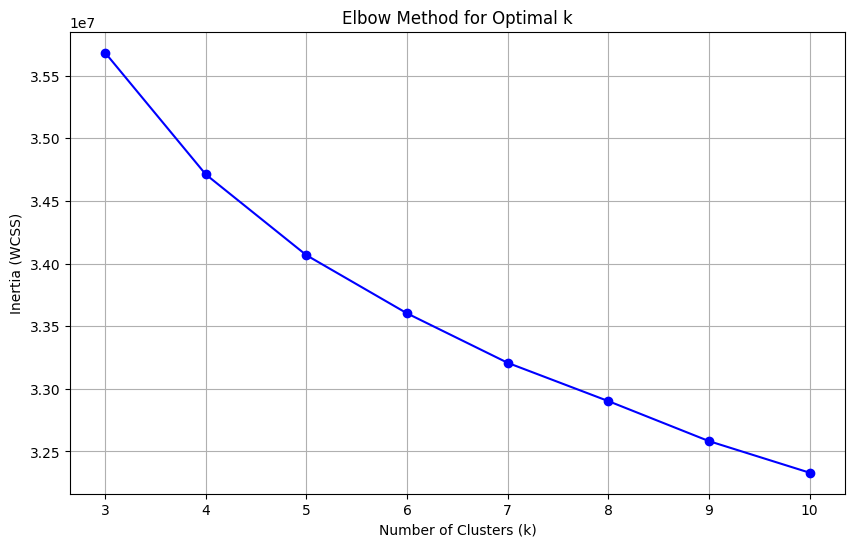

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

Starting extended Elbow Method (k=3 to k=20)...
k=3 completed in 4.75s | Inertia: 35,683,224.01
k=4 completed in 4.12s | Inertia: 34,711,597.65
k=5 completed in 12.65s | Inertia: 34,066,582.45
k=6 completed in 16.42s | Inertia: 33,602,229.85
k=7 completed in 37.69s | Inertia: 33,207,253.51
k=8 completed in 24.76s | Inertia: 32,901,651.79
k=9 completed in 12.11s | Inertia: 32,582,181.71
k=10 completed in 11.38s | Inertia: 32,330,008.95
k=11 completed in 39.01s | Inertia: 32,102,684.43
k=12 completed in 19.33s | Inertia: 31,894,788.91
k=13 completed in 20.35s | Inertia: 31,716,637.18
k=14 completed in 18.97s | Inertia: 31,564,020.63
k=15 completed in 24.42s | Inertia: 31,419,120.68
k=16 completed in 36.27s | Inertia: 31,288,291.50
k=17 completed in 51.50s | Inertia: 31,166,683.34
k=18 completed in 51.73s | Inertia: 31,055,466.15
k=19 completed in 56.33s | Inertia: 30,952,080.95
k=20 completed in 51.89s | Inertia: 30,849,676.68


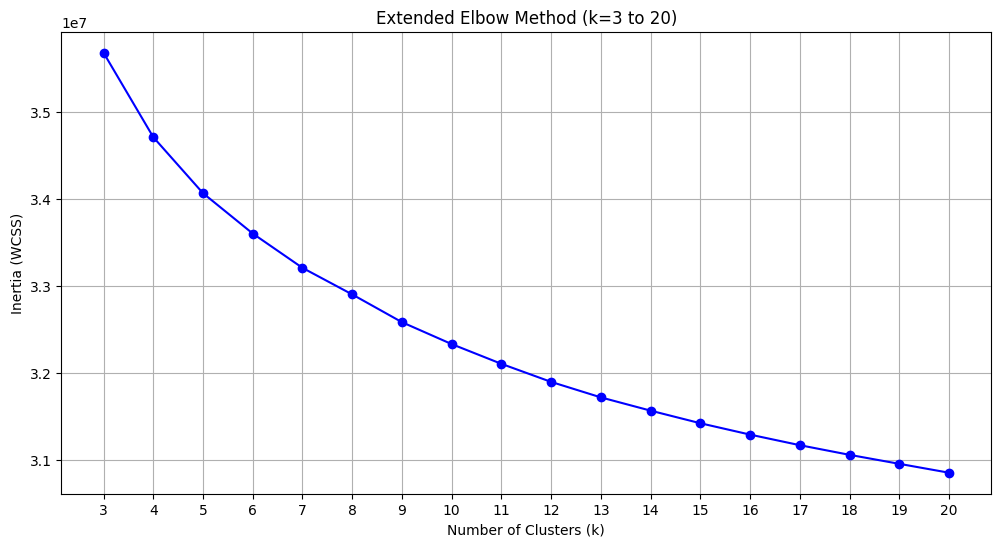

In [ ]:
inertia_values_ext = []
k_range_ext = range(3, 21)

print("Starting extended Elbow Method (k=3 to k=20)...")
for k in k_range_ext:
    start_time = time.time()
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia_values_ext.append(kmeans.inertia_)
    end_time = time.time()
    print(f"k={k} completed in {end_time - start_time:.2f}s | Inertia: {kmeans.inertia_:,.2f}")

# Plotting the extended results
plt.figure(figsize=(12, 6))
plt.plot(k_range_ext, inertia_values_ext, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Extended Elbow Method (k=3 to 20)')
plt.xticks(k_range_ext)
plt.grid(True)
plt.show()

### 3.2 Silhouette Analysis
The Silhouette Score measures how similar a point is to its own cluster compared to others. A higher score indicates better separation. Because this calculation is memory-intensive, we compute it on a representative sample of 10,000 points.

### 3.2 Silhouette Analysis
The Silhouette Score measures how similar a point is to its own cluster compared to others. A higher score indicates better separation. Because this calculation is memory-intensive, we compute it on a representative sample of 10,000 points.

### 3.2 Silhouette Analysis
The Silhouette Score measures how similar a point is to its own cluster compared to others. A higher score indicates better separation. Because this calculation is memory-intensive ($O(N^2)$), we compute it on a representative sample of 10,000 points.

Starting Elbow Method with RAW data (X) using k-means++...
k=3 completed in 6.45s | Raw Inertia: 44,574,563.03
k=4 completed in 5.38s | Raw Inertia: 43,359,308.47
k=5 completed in 9.75s | Raw Inertia: 42,668,759.26
k=6 completed in 8.67s | Raw Inertia: 42,018,277.04
k=7 completed in 17.00s | Raw Inertia: 41,468,995.74
k=8 completed in 18.18s | Raw Inertia: 41,065,602.90
k=9 completed in 13.88s | Raw Inertia: 40,693,447.59
k=10 completed in 30.64s | Raw Inertia: 40,376,256.54
k=11 completed in 16.30s | Raw Inertia: 40,102,615.68
k=12 completed in 20.75s | Raw Inertia: 39,852,743.82
k=13 completed in 17.07s | Raw Inertia: 39,628,895.12
k=14 completed in 32.97s | Raw Inertia: 39,419,251.44
k=15 completed in 26.05s | Raw Inertia: 39,253,017.79
k=16 completed in 46.71s | Raw Inertia: 39,082,362.54
k=17 completed in 52.08s | Raw Inertia: 38,937,309.47
k=18 completed in 52.18s | Raw Inertia: 38,789,239.87
k=19 completed in 47.83s | Raw Inertia: 38,647,316.95
k=20 completed in 38.03s | Raw Ine

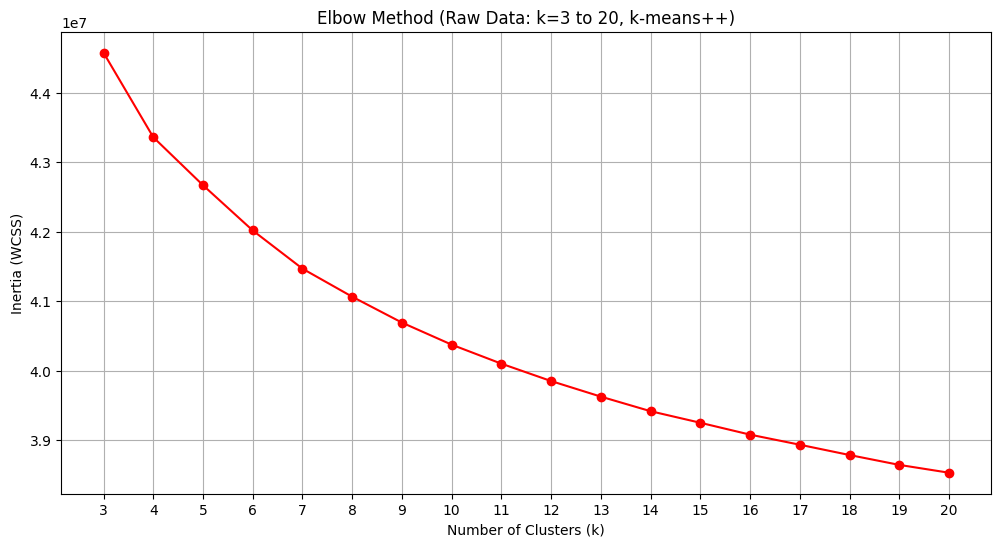

In [ ]:
inertia_values_raw = []
k_range_raw = range(3, 21)

print("Starting Elbow Method with RAW data (X) using k-means++...")
for k in k_range_raw:
    start_time = time.time()
    # Explicitly setting init='k-means++' and using raw X
    kmeans_raw = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans_raw.fit(X)
    inertia_values_raw.append(kmeans_raw.inertia_)
    end_time = time.time()
    print(f"k={k} completed in {end_time - start_time:.2f}s | Raw Inertia: {kmeans_raw.inertia_:,.2f}")

# Plotting the raw data results
plt.figure(figsize=(12, 6))
plt.plot(k_range_raw, inertia_values_raw, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method (Raw Data: k=3 to 20, k-means++)')
plt.xticks(k_range_raw)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# SILHOUETTE SCORE
# This measures how similar an object is to its own cluster compared to other clusters.
# Scores range from -1 to 1; higher scores indicate better-defined clusters.
# Because this is computationally expensive, we use a random sample of 10,000 points.

sample_size = 10000
indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[indices]

silhouette_avg = []
for k in range(3, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sample)
    silhouette_avg.append(silhouette_score(X_sample, labels))

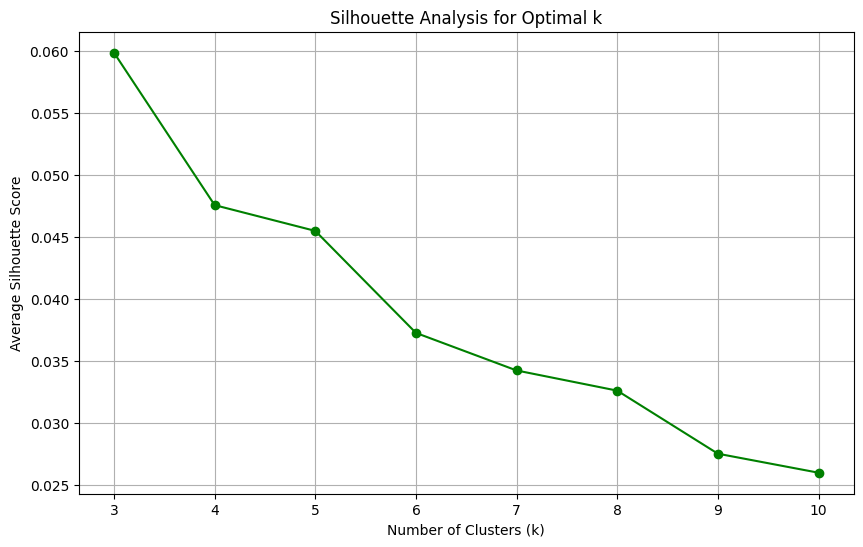

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_avg, 'go-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.grid(True)
plt.show()

### 3.3 Davies-Bouldin Index
This index signifies the average 'similarity' between clusters. In this case, **lower is better**. It helps identify the number of clusters that are most distinct and least overlapping.

### 3.3 Davies-Bouldin Index
This index signifies the average 'similarity' between clusters. In this case, **lower is better**. It helps identify the number of clusters that are most distinct and least overlapping.

### 3.3 Davies-Bouldin Index
This index signifies the average 'similarity' between clusters. In this case, **lower is better**. It helps identify the number of clusters that are most distinct and least overlapping.

In [ ]:
from sklearn.metrics import davies_bouldin_score

# DAVIES-BOULDIN INDEX
# This index calculates the average similarity between each cluster and its most similar one.
# Unlike the silhouette score, a LOWER score indicates better cluster separation.

davies_bouldin_avg = []
for k in range(3, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sample)
    score = davies_bouldin_score(X_sample, labels)
    davies_bouldin_avg.append(score)

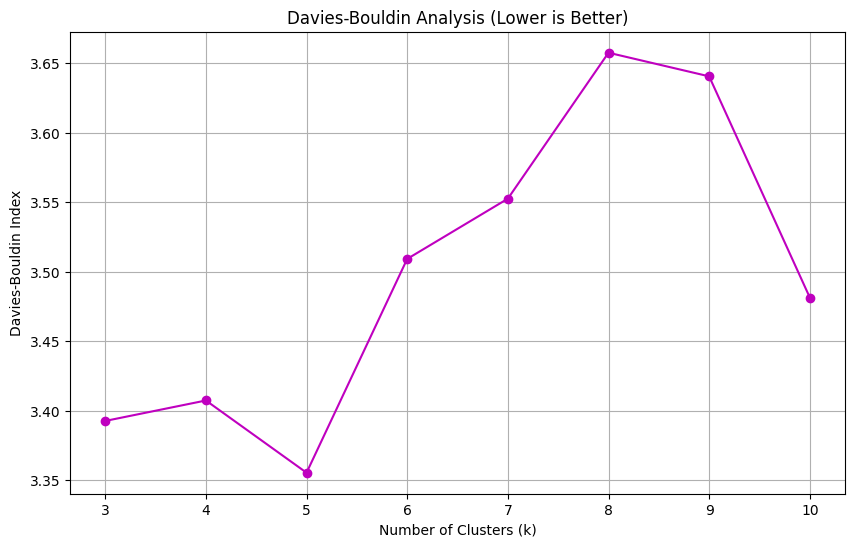

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range_db, davies_bouldin_avg, 'mo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Analysis (Lower is Better)')
plt.grid(True)
plt.show()

### 3.4 Calinski-Harabasz Index
Also known as the Variance Ratio Criterion, this index calculates the ratio of between-cluster dispersion to within-cluster dispersion. **Higher scores** typically indicate better-defined clusters.

### 3.4 Calinski-Harabasz Index
Also known as the Variance Ratio Criterion, this index calculates the ratio of between-cluster dispersion to within-cluster dispersion. **Higher scores** typically indicate better-defined clusters.

### 3.4 Calinski-Harabasz Index
Also known as the Variance Ratio Criterion, this index calculates the ratio of between-cluster dispersion to within-cluster dispersion. **Higher scores** typically indicate better-defined clusters.

In [ ]:
from sklearn.metrics import calinski_harabasz_score

# CALINSKI-HARABASZ INDEX (Variance Ratio Criterion)
# This index is the ratio of the sum of between-cluster dispersion and within-cluster dispersion.
# Higher values indicate that clusters are dense and well-separated.

calinski_harabasz_avg = []
for k in range(3, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sample)
    score = calinski_harabasz_score(X_sample, labels)
    calinski_harabasz_avg.append(score)

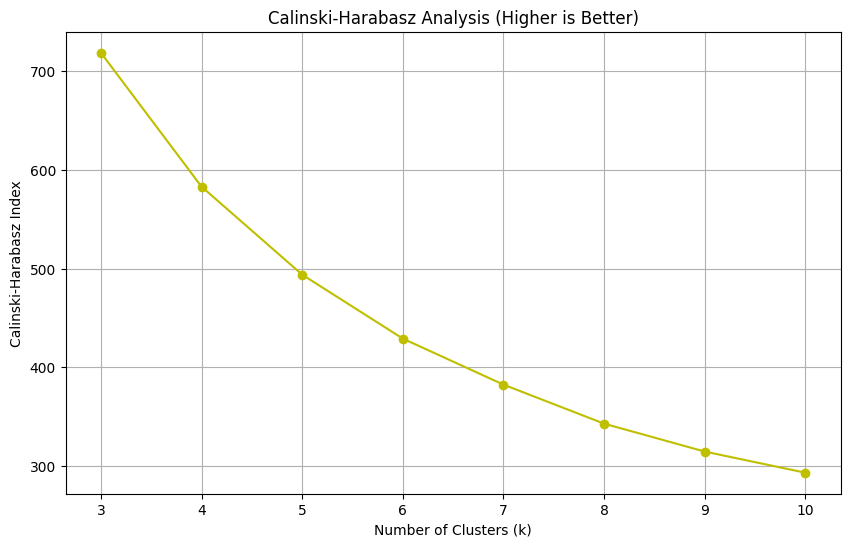

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range_ch, calinski_harabasz_avg, 'yo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Analysis (Higher is Better)')
plt.grid(True)
plt.show()

## 4. Final Diagnostic Summary

After running a suite of clustering metrics on the 120-dimensional dataset, we observed the following:

- **Elbow Method**: Shows a smooth decline, suggesting that personality types are continuous. There is a minor inflection point at **k=5**.
- **Silhouette Score**: Highest at **k=3** (0.06), indicating that the data is most distinct when broadly grouped.
- **Davies-Bouldin Index**: Reaches its best (lowest) score at **k=5**, which suggests higher internal consistency for a 5-cluster model.
- **Calinski-Harabasz Index**: Maximized at **k=3**, aligning with the Silhouette Score regarding variance ratios.

### **Decision**
Mathematically, **k=3** provides the most separation, but **k=5** is theoretically more robust for personality analysis and is supported by the Davies-Bouldin index.

## 4. Final Diagnostic Summary

After running a suite of clustering metrics on the 120-dimensional dataset, we observed the following:

- **Elbow Method**: Shows a smooth decline, suggesting that personality types are continuous. There is a minor inflection point at **k=5**.
- **Silhouette Score**: Highest at **k=3** (0.06), indicating that the data is most distinct when broadly grouped.
- **Davies-Bouldin Index**: Reaches its best (lowest) score at **k=5**, which suggests higher internal consistency for a 5-cluster model.
- **Calinski-Harabasz Index**: Maximized at **k=3**, aligning with the Silhouette Score regarding variance ratios.

### **Decision**
Mathematically, **k=3** provides the most separation, but **k=5** is theoretically more robust for personality analysis and is supported by the Davies-Bouldin index.